<a href="https://colab.research.google.com/github/mafemi/Brain-MRI-Triage-System/blob/main/Multi_Class_Brain_MRI_Triage_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Class Brain MRI Triage System Using Convolutional Neural Networks and Vision Transformer Architectures

### LIBRARY IMPORT

In [2]:
import os # For file path operations
import torch # For tensor operations and deep learning
import torch.nn as nn # For building neural network layers
import matplotlib.pyplot as plt # For plotting graphs and visualizations
import seaborn as sns # For enhanced data visualization
import random # For reproducibility in dataset splitting
import numpy as np # For numerical operations
from PIL import Image # For image processing
from torchvision import datasets, transforms as T, models as models # For dataset handling, data transformations, and pre-trained models
from torch.utils.data import DataLoader, random_split # For loading data in batches and splitting datasets
print(f'PyTorch version: {torch.__version__}')
# import tensorflow as tf
# print(f'TensorFlow version: {tf.__version__}')

PyTorch version: 2.11.0+cu128


In [3]:
# SEED FOR REPRODUCIBILITY

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # Set the seed for PyTorch to ensure reproducibility of results across different runs. This is crucial for debugging and comparing model performance, as it ensures that the same random numbers are generated for operations like weight initialization and data shuffling.
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

print("Setting random seed 42 for reproducibility...")
seed_everything(42)

Setting random seed 42 for reproducibility...


In [4]:
### CONFIGURE ENVIRONMENT & DIRECTORY
RUNNING_IN_COLAB = True  # Set to False if running locally

if RUNNING_IN_COLAB:
  from google.colab import drive
  # Mount Google Drive
  print("Mounting Google Drive...")
  drive.mount('/content/drive')
  BASE_DIR = '/content/drive/MyDrive/Brain_MRI_Triage_System'
  print(f"Project directory is mounted and ready: {BASE_DIR}")

else:
  BASE_DIR = os.path.join(os.getcwd(), 'Brain_MRI_Triage_System')
  print("Running locally. Bypassing Google Drive mount.")

# Create project directory in google drive
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'data'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'models'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'logs'), exist_ok=True)


### HARDWARE CHECK
# Verify GPU Provisioning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("\n--- Hardware Check ---")
print(f"Compute Device: {device}")
if device.type == 'cuda':
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Allocated: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Mounting Google Drive...
Mounted at /content/drive
Project directory is mounted and ready: /content/drive/MyDrive/Brain_MRI_Triage_System

--- Hardware Check ---
Compute Device: cuda
GPU Model: Tesla T4
VRAM Allocated: 15.64 GB


In [5]:
data_dir = os.path.join(BASE_DIR, 'data')
train_dir = os.path.join(data_dir, 'Training')
test_dir = os.path.join(data_dir, 'Testing')

if os.path.exists(train_dir) and os.path.exists(test_dir):
  print(f"Success: Training directory found at {train_dir}")
  print(f"Success: Testing directory found at {test_dir}")
else:
  print("ERROR: Missing required dataset directories.")
  if not os.path.exists(train_dir):
    print(f"Missing Training folder: Expected at {train_dir}")
  if not os.path.exists(test_dir):
    print(f"Missing Testing folder: Expected at {test_dir}")
  print(f"\nAction Required: Please ensure the dataset is extracted into: {data_dir}")

Success: Training directory found at /content/drive/MyDrive/Brain_MRI_Triage_System/data/Training
Success: Testing directory found at /content/drive/MyDrive/Brain_MRI_Triage_System/data/Testing


### EXPLORATORY DATA ANALYSIS


Class Distribution in Training Set:
 - meningioma: 1400 images
 - glioma: 1400 images
 - notumor: 1400 images
 - pituitary: 1400 images


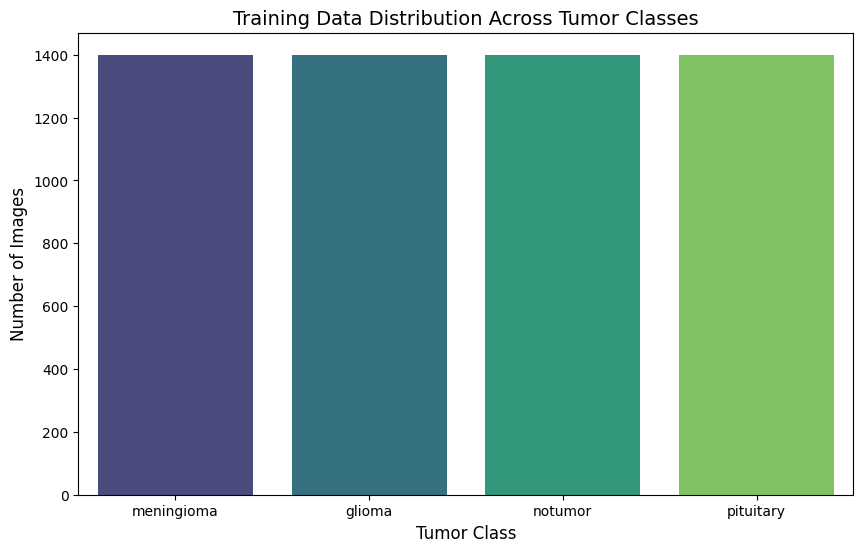

In [6]:
### EXPLORATORY DATA ANALYSIS
classes = os.listdir(train_dir)
class_counts = {}

for cls in classes:
  class_path = os.path.join(train_dir, cls)
  if os.path.isdir(class_path):
    class_counts[cls] = len(os.listdir(class_path))

print("\nClass Distribution in Training Set:")
for cls, count in class_counts.items():
  print(f" - {cls}: {count} images")

# Distribution Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), hue=list(class_counts.keys()), legend=False, palette='viridis')
plt.title('Training Data Distribution Across Tumor Classes', fontsize=14)
plt.xlabel('Tumor Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.show()


Class Distribution in Testing Set:
 - meningioma: 400 images
 - glioma: 400 images
 - notumor: 400 images
 - pituitary: 400 images


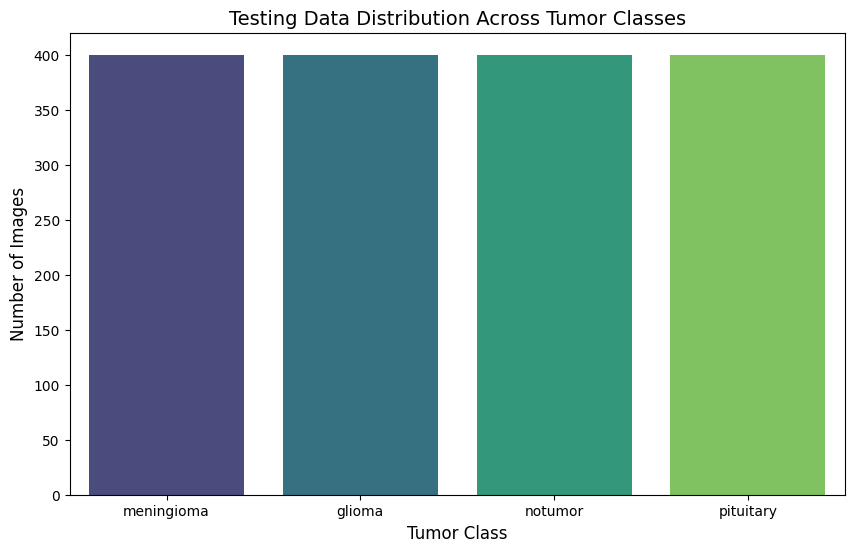

In [7]:
classes = os.listdir(train_dir)
class_counts = {}

for cls in classes:
  class_path = os.path.join(test_dir, cls)
  if os.path.isdir(class_path):
    class_counts[cls] = len(os.listdir(class_path))

print("\nClass Distribution in Testing Set:")
for cls, count in class_counts.items():
  print(f" - {cls}: {count} images")

# Distribution Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), hue=list(class_counts.keys()), legend=False, palette='viridis')
plt.title('Testing Data Distribution Across Tumor Classes', fontsize=14)
plt.xlabel('Tumor Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.show()

In [8]:
classes = sorted(os.listdir(train_dir))

widths, heights = [], []
channels = []
pixel_intensities = []
sample_images = []

histogram_bins = 50
global_pixel_counts = np.zeros(histogram_bins)
bin_edges = np.linspace(0, 256, histogram_bins + 1)


# We sample 150 images per class for pixel intensity
INTENSITY_SAMPLE_SIZE = 150

print("Scanning image dimensions, color channels, and pixel intensities... (This may take a minute)")

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    if not os.path.isdir(class_path): continue

    images = os.listdir(class_path)

    # 1. Grab a random image for the Clinical Grid
    random_img_name = random.choice(images)
    sample_images.append({
        'class': cls,
        'path': os.path.join(class_path, random_img_name)
    })

    # Select a random subset for pixel intensity analysis
    intensity_subset = set(random.sample(images, min(INTENSITY_SAMPLE_SIZE, len(images))))

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                # Image Dimensions
                widths.append(img.width)
                heights.append(img.height)
                # Color Channels ('L' = Grayscale, 'RGB' = Color)
                channels.append(img.mode)


                # Pixel Intensities (Subset only)
                if img_name in intensity_subset:
                    # Convert to grayscale array to analyze structural contrast
                    img_gray = img.convert('L')
                    img_array = np.array(img_gray).flatten()
                    counts, _ = np.histogram(img_array, bins=bin_edges)
                    global_pixel_counts += counts
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

Scanning image dimensions, color channels, and pixel intensities... (This may take a minute)


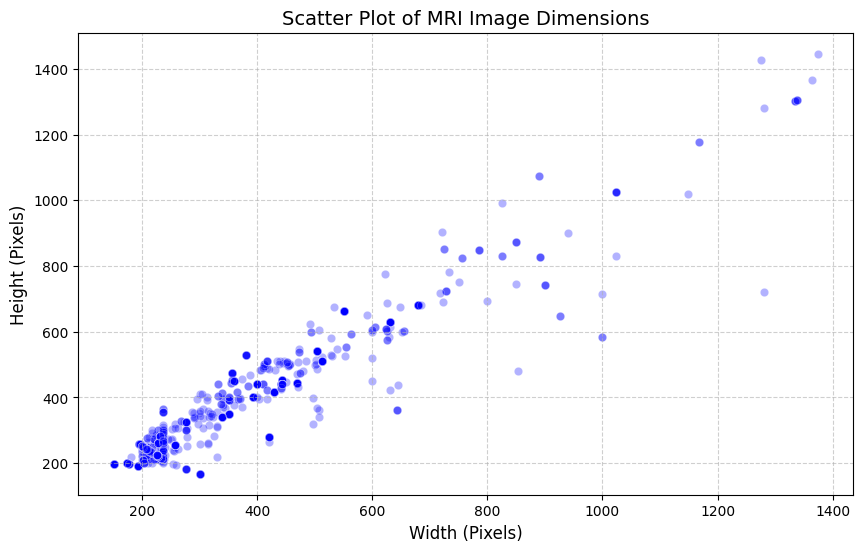


Color Channel Distribution across Training Set:
 - Grayscale (1-channel): 2358 images
 - P: 1 images
 - RGB (3-channel): 3238 images
 - RGBA: 3 images


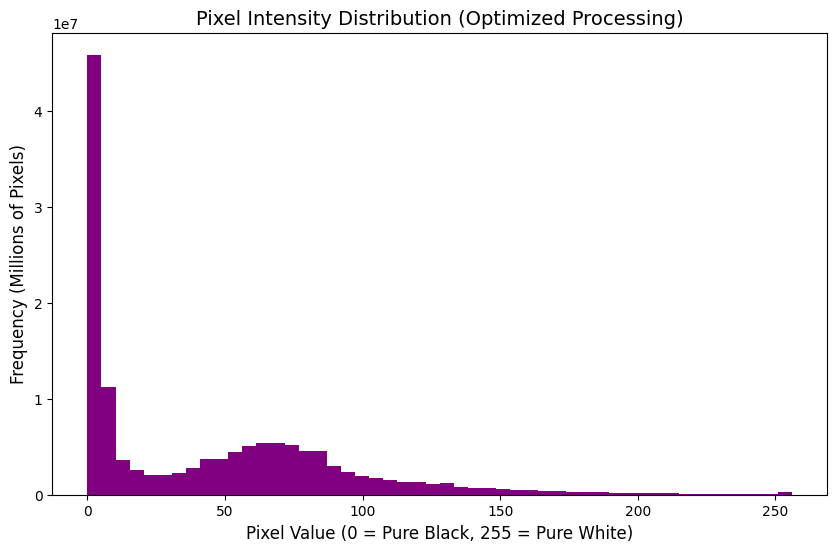

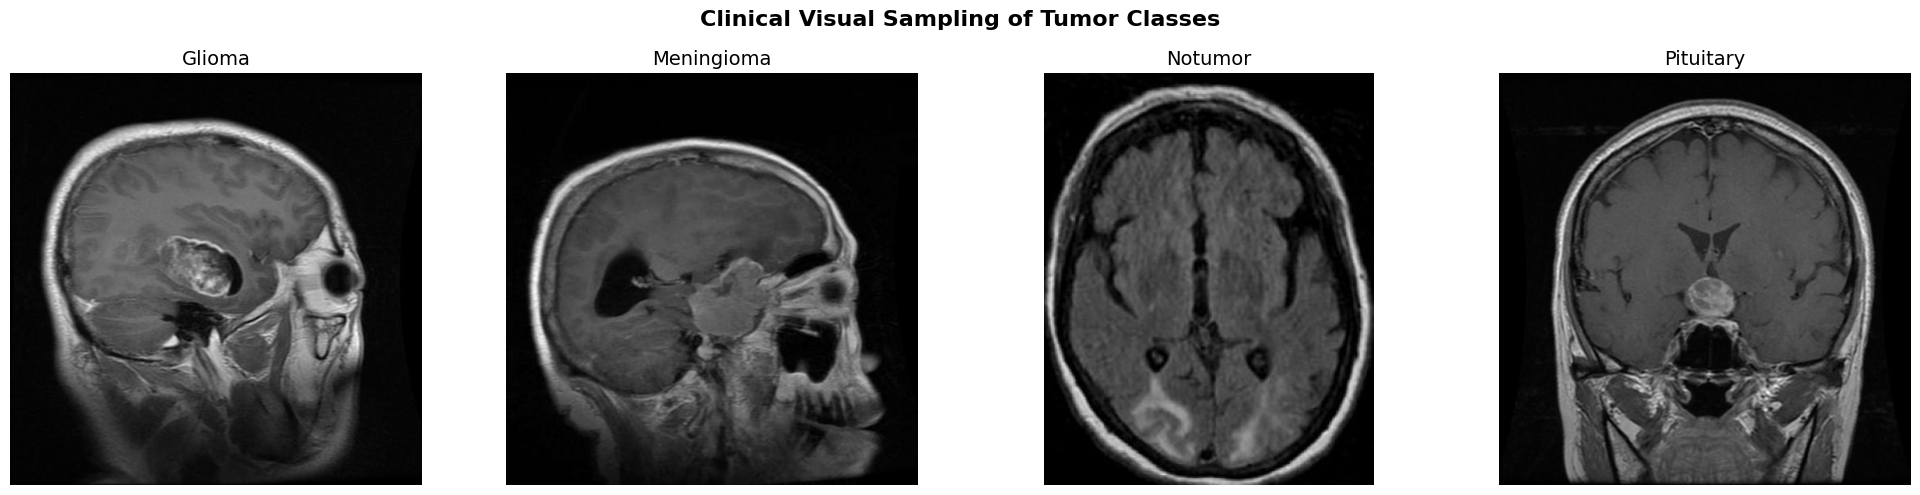

In [9]:
# 1: Dimensional Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=widths, y=heights, alpha=0.3, color='blue')
plt.title('Scatter Plot of MRI Image Dimensions', fontsize=14)
plt.xlabel('Width (Pixels)', fontsize=12)
plt.ylabel('Height (Pixels)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2: Color Channel Distribution
unique_channels, counts = np.unique(channels, return_counts=True)
print("\nColor Channel Distribution across Training Set:")
for ch, count in zip(unique_channels, counts):
    ch_name = "Grayscale (1-channel)" if ch == 'L' else "RGB (3-channel)" if ch == 'RGB' else ch
    print(f" - {ch_name}: {count} images")

# 3: Pixel Intensity Histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], global_pixel_counts, width=(256/histogram_bins), color='purple', align='edge')
plt.title('Pixel Intensity Distribution (Optimized Processing)', fontsize=14)
plt.xlabel('Pixel Value (0 = Pure Black, 255 = Pure White)', fontsize=12)
plt.ylabel('Frequency (Millions of Pixels)', fontsize=12)
plt.show()

# 4: Clinical Visual Grid
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Clinical Visual Sampling of Tumor Classes', fontsize=16, weight='bold')

for ax, item in zip(axes, sample_images):
    img = Image.open(item['path'])
    ax.imshow(img, cmap='gray')
    ax.set_title(item['class'].capitalize(), fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

### DATA PREPARATION

In [10]:
# IMAGE TRANSFORMATIONS
# We standardize all images to RGB and resize to 224x224 for model compatibility, as well as applying ImageNet normalization since we will be using a pretrained model.
# The augmentation techniques (RandomHorizontalFlip and RandomRotation) are applied with a 50% chance to increase the diversity of the training data, which can help the model generalize better to unseen data. The normalization step ensures that the pixel values are scaled appropriately for the pretrained model's expectations.
train_transforms = T.Compose([
    T.Lambda(lambda img: img.convert('RGB')), # Standardising all image files as RGB
    T.Resize((224, 224)),                     # Standardizing images file size as 224 x 224
    T.RandomHorizontalFlip(p=0.5),            # Data Augmentation (50% chance to flip horizontally to simulate different orientations)
    T.RandomRotation(15),                     # Data Augmentation (rotate by up to 15 degrees to simulate different orientations)
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# Testing/Validation transforms strictly resize and normalize (NO augmentation)
# We maintain the same RGB conversion, resizing, and normalization to ensure that the evaluation data is processed in a consistent manner with the training data, minus the augmentation which is only applied during training to enhance generalization.
eval_transforms = T.Compose([
    T.Lambda(lambda img: img.convert('RGB')),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
# DATASET SPLITTING (Train / Validation)
# Load the full training directory, which contains all the images and their corresponding labels. This dataset will be used to create both the training and validation sets. By binding the transform recipes at this stage, we ensure that when the DataLoader eventually calls for the images, data augmentation is exclusively executed on the training subset after the split, while the validation subset will be transformed separately without augmentation.
base_train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
base_val_dataset = datasets.ImageFolder(root=train_dir, transform=eval_transforms)

# Calculate the 80/20 split mathematically to ensure we have a clear separation of training and validation data, which is crucial for unbiased model evaluation. By using a fixed random seed, we guarantee that the split is reproducible across different runs, allowing for consistent results and easier debugging.
val_size = int(0.2 * len(base_train_dataset))
train_size = len(base_train_dataset) - val_size

# Split the dataset using the locked random seed for reproducibility and to ensure that the training and validation sets are mutually exclusive, which is essential for an unbiased evaluation of the model's performance on unseen data. By creating separate datasets for training and validation, we can apply different transformations (augmentation for training and no augmentation for validation) to better simulate real-world conditions during model evaluation.
train_dataset, _ = random_split(base_train_dataset, [train_size, val_size])
_, val_dataset = random_split(base_val_dataset, [train_size, val_size])

# Load the separate Testing directory
test_dataset = datasets.ImageFolder(root=test_dir, transform=eval_transforms)

In [12]:
# DATALOADERS (Batching for the GPU)
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Data Engineering Complete:")
print(f" - Training Set: {len(train_dataset)} images (Batches: {len(train_loader)})")
print(f" - Validation Set: {len(val_dataset)} images (Batches: {len(val_loader)})")
print(f" - Testing Set: {len(test_dataset)} images (Batches: {len(test_loader)})")

Data Engineering Complete:
 - Training Set: 4480 images (Batches: 140)
 - Validation Set: 1120 images (Batches: 35)
 - Testing Set: 1600 images (Batches: 50)


### ResNet50 MODEL ADAPTATION

In [13]:
print("Initializing and Adapting ResNet50...")
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

Initializing and Adapting ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


In [14]:
# Freeze the convolution layers (Feature Extractor)
for param in resnet50.parameters():
    param.requires_grad = False

# Replace the final classification head
# ResNet50's default final layer was built for 1000 ImageNet classes. We need 4.
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 4) # 4 classes: Glioma, Meningioma, No Tumor, Pituitary
)


# Send the model to the GPU
resnet50 = resnet50.to(device)
print("ResNet50 successfully adapted and loaded onto:", device)

ResNet50 successfully adapted and loaded onto: cuda


### ResNet50 MODEL TRAINING

In [15]:
import time

print("\n--- Starting Phase 2: Model Training ---")

# 1. Define the Judge and the Optimizer
# CrossEntropy is the mathematical standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam is a highly efficient optimizer. Notice we are ONLY giving it the new 'fc' layer to train.
optimizer = torch.optim.Adam(resnet50.fc.parameters(), lr=0.001)

EPOCHS = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print(f"Igniting Training Engine for {EPOCHS} Epochs on {device}...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # ==========================
    # 1. TRAINING PHASE
    # ==========================
    resnet50.train() # Unlocks the brain for learning
    running_loss, correct_train, total_train = 0.0, 0, 0

    # Pull batches of 32 from the conveyor belt
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device) # Move data to T4 GPU

        optimizer.zero_grad() # Wipe the whiteboard clean from the last batch

        outputs = resnet50(inputs) # Forward pass: Model makes a guess
        loss = criterion(outputs, labels) # The judge calculates the error

        loss.backward() # Backward pass: Calculate how to fix the error
        optimizer.step() # Apply the fixes to the brain

        # Track the math for our graphs later
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # ==========================
    # 2. VALIDATION PHASE
    # ==========================
    resnet50.eval() # Locks the brain. No learning allowed.
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad(): # Disables PyTorch's memory tracking to save VRAM
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet50(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    # Save the stats for this epoch
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_time:.0f}s) - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

total_time = (time.time() - start_time) / 60
print(f"\nTraining Complete in {total_time:.2f} minutes!")


--- Starting Phase 2: Model Training ---
Igniting Training Engine for 10 Epochs on cuda...
Epoch [1/10] (46s) - Train Loss: 0.6404, Train Acc: 0.7629 | Val Loss: 0.5983, Val Acc: 0.7688
Epoch [2/10] (43s) - Train Loss: 0.4986, Train Acc: 0.8074 | Val Loss: 0.3384, Val Acc: 0.8804
Epoch [3/10] (43s) - Train Loss: 0.4287, Train Acc: 0.8431 | Val Loss: 0.3232, Val Acc: 0.8848
Epoch [4/10] (42s) - Train Loss: 0.3993, Train Acc: 0.8502 | Val Loss: 0.3666, Val Acc: 0.8652
Epoch [5/10] (44s) - Train Loss: 0.3814, Train Acc: 0.8536 | Val Loss: 0.3234, Val Acc: 0.8732
Epoch [6/10] (44s) - Train Loss: 0.3632, Train Acc: 0.8636 | Val Loss: 0.3573, Val Acc: 0.8714
Epoch [7/10] (43s) - Train Loss: 0.3547, Train Acc: 0.8638 | Val Loss: 0.2646, Val Acc: 0.9018
Epoch [8/10] (44s) - Train Loss: 0.3571, Train Acc: 0.8647 | Val Loss: 0.2679, Val Acc: 0.9000
Epoch [9/10] (44s) - Train Loss: 0.3514, Train Acc: 0.8676 | Val Loss: 0.2614, Val Acc: 0.9054
Epoch [10/10] (43s) - Train Loss: 0.3660, Train Acc: 